### Include a probabilistic CNOT-gate, with RUS to the circuit (or tableau simulator)

In [2]:
import numpy as np
import networkx as nx
from tqdm.notebook import tqdm
import sys
sys.path.insert(0, '..')
from lib.circuitSolver import *
from lib.generate_graph import *
from lib.tableau import *
from lib.LC_edge_reduction import *
from optimization_script import *
from utils.ufuncs import *
from lib.graphs import *

In [2]:
graph = nx.Graph()
graph.add_edges_from([(0,1),(0,2),(1,2),(1,3),(2,3)])
#graph.add_edges_from(ring_resource_qpc(6,2,2,(1,2,3,4))[1])
tableau = stabTableau.get_tableau_from_graph(graph)
ops,cnots = algorithm(tableau,optimize=True,return_num_cnots=True)
print(f'Emission circuit has {cnots} em-CNOT gates')

Emission circuit has 2 em-CNOT gates


now use the operations for a new circuit generation with RUS-CZ-gates

P_RUS_succes = 0.5 P_RUS_failure = 0.0 P_RUS_abort = 0.5


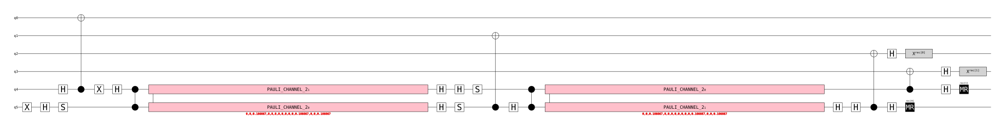

In [3]:
RUS_circuit = generationSequenceRUS(ops, 1,1)
RUS_circuit.diagram('timeline-svg')

In [4]:
def check_circuit_offline(generation_circuit, pauliStrings, num_shots=10):
    circuit = generation_circuit.copy()
    stab_generators = stabTableau.stim_stab_generators(pauliStrings)
    test_result = np.zeros(len(pauliStrings), dtype=bool)
    for i in range(len(stab_generators)):
        circuit.append('MPP', stab_generators[i])
        circuit.append('Detector', [stim.target_rec(-1)])
    sampler = circuit.compile_detector_sampler()
    test_result = sampler.sample(shots=num_shots)
    #     if not np.all(sampler.sample(shots=num_shots) == False):
    #         print("Circuit generates wrong graph")
    #         print(stab_generators[i])
    #         test_result[i] = True
    #         temp_circuit.diagram('timeline-svg')
    # if np.all(test_result == False):
    #     print("Circuit generates correct graph")
    return test_result

In [5]:
result = check_circuit_offline(RUS_circuit,tableau.pauliStrings0,num_shots=1000000)
succeeded = 0
failed = 0
for i in result:
    if not np.all(i == False):
        failed +=1
    else:
        succeeded += 1
print(succeeded,failed)
print(succeeded/(succeeded+failed))

277047 722953
0.277047


### The success probabilities are too high, so try with the stim.TableauSimulator

In [3]:
import graphiq

from graphiq.backends.state_rep_conversion import _graph_finder

We can simulate the actions on the tableau replacing each emitter entangling with RUS and the corresponding outcomes. Use external libraries to find the graph state that is local clifford equivalent if entangling gate fails (not practicable for real use because we have a mixture in real systems)

Emission circuit has 3 em-CNOT gates
P_RUS_succes = 0.6548765624999998 P_RUS_failure = 0.17767653758542157 P_RUS_abort = 0.16744689991457862
RUS-CNOT-gate aborted
RUS-CNOT-gate succeeded
RUS-CNOT-gate aborted
[False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, True, False, False]
[stim.PauliString("+X__X__"), stim.PauliString("+ZXZZ__"), stim.PauliString("+_Z_X__"), stim.PauliString("+__XX__"), stim.PauliString("-____Z_"), stim.PauliString("-_____Z")]


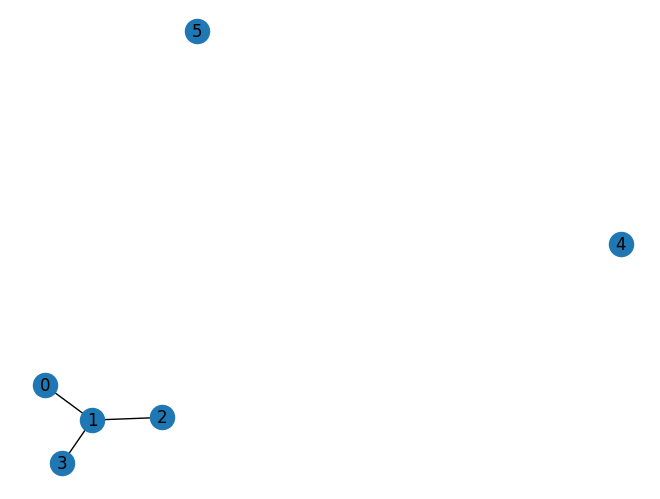

In [8]:
graph = nx.Graph()
graph.add_edges_from([(0,1),(0,2),(1,2),(1,3),(2,3)])
#graph.add_edges_from(ring_resource_qpc(6,2,2,(1,2,3,4))[1])
tableau = stabTableau.get_tableau_from_graph(graph)
ops,cnots = algorithm(tableau,optimize=False,return_num_cnots=True)
print(f'Emission circuit has {cnots} em-CNOT gates')
generation_tableau = Tableau_generationSequenceRUS(ops, 0.95,2,without_noise=False,number_of_cnots=3)
print(check_tableau(generation_tableau,tableau.pauliStrings0))
generation_tableau = generation_tableau.canonical_stabilizers()
print(generation_tableau)
new_tableau = tableau.tableau_from_Paulistrings(pauliStrings=generation_tableau, overwrite=False)
x_stab, z_stab = np.hsplit(new_tableau,2)
new_graph,_ = _graph_finder(x_stab,z_stab, get_ops_data=True) # might give an error because this function doesnt take the signs, could use the Julia package Jabalizer
nx.draw(new_graph,with_labels=True)

But we have to create the tableau multiple times to get a total probability of successful creation which makes it slow

In [8]:
tableau = stabTableau.get_tableau_from_graph(graph)
ops,cnots = algorithm(tableau,optimize=False,return_num_cnots=True)
print(f'Emission circuit has {cnots} em-CNOT gates')
succeeded = 0
failed = 0
for i in tqdm(range(int(5e4))):
    generation_tableau = Tableau_generationSequenceRUS(ops, 0.6,2,without_noise=False)
    if np.all(np.array(check_tableau(generation_tableau,tableau.pauliStrings0)) == False):
        succeeded += 1
    else:
        failed+=1

print('Graph generation probability: ',succeeded/(succeeded+failed))

Emission circuit has 3 em-CNOT gates


  0%|          | 0/50000 [00:00<?, ?it/s]

P_RUS_succes = 0.21239999999999998 P_RUS_failure = 0.7804878048780488 P_RUS_abort = 0.00711219512195127
RUS-CNOT-gate failed with error ZxX
RUS-CNOT-gate failed with error IxX
RUS-CNOT-gate failed with error IxX
P_RUS_succes = 0.21239999999999998 P_RUS_failure = 0.7804878048780488 P_RUS_abort = 0.00711219512195127
RUS-CNOT-gate failed with error ZxI
RUS-CNOT-gate failed with error IxX
RUS-CNOT-gate failed with error IxX
P_RUS_succes = 0.21239999999999998 P_RUS_failure = 0.7804878048780488 P_RUS_abort = 0.00711219512195127
RUS-CNOT-gate failed with error IxI
RUS-CNOT-gate succeeded
RUS-CNOT-gate failed with error IxX
P_RUS_succes = 0.21239999999999998 P_RUS_failure = 0.7804878048780488 P_RUS_abort = 0.00711219512195127
RUS-CNOT-gate failed with error IxX
RUS-CNOT-gate failed with error IxI
RUS-CNOT-gate failed with error ZxX
P_RUS_succes = 0.21239999999999998 P_RUS_failure = 0.7804878048780488 P_RUS_abort = 0.00711219512195127
RUS-CNOT-gate failed with error IxI
RUS-CNOT-gate failed wit

<p>If we compare a RUS-gate to the boosted fusion with redundant encoding under photon loss. We can look at the demand of detection probability such that the success probability of boosted fusion gate exceeds the one of the RUS-gate</p>

$\begin{align}
\frac{\eta_{RUS}^2}{2}\frac{1-(\frac{\eta^2_{RUS}}{2})^{k_{RUS}}}{1-\frac{\eta^2_{RUS}}{2}} = (1-\frac{1}{2^{k_\text{opt}}})\eta_{B}^{2k_\text{opt}}\\
\sqrt[2k_\text{opt}]{\frac{\eta_{RUS}^2}{2}\frac{1-(\frac{\eta^2_{RUS}}{2})^{k_{RUS}}}{(1-\frac{\eta^2_{RUS}}{2}) (1-2^{-k_\text{opt}})}}=\eta_B
\end{align}$
Assuming in the "lossy" regime eta<0.9 where only normal fusion is possible so $$k_{opt}=1$$
$\begin{align}
\eta_{RUS}\sqrt{\frac{2^{1-k_{RUS}}\eta_{RUS}^{2k_{RUS}}-2}{\eta_{RUS}^2-2}}=\eta_B\\
1\leq\sqrt{\frac{2^{1-k_{RUS}}\eta_{RUS}^{2k_{RUS}}-2}{\eta_{RUS}^2-2}}=\frac{\eta_B}{\eta_{RUS}}
\end{align}$
This means to achive the same success probability in the very lossy (current) regime the detection probability for fusion must be greater than the one of RUS-CZ gates as soon as we have more than one trial for RUS.

In [9]:
eta_RUS = 0.8
k_RUS = 2
k_opt = 1
print(f'For eta_RUS = {eta_RUS} with {k_RUS} trials we require eta_B = '+ str(eta_RUS*np.sqrt((2**(1-k_RUS)*eta_RUS**(2*k_RUS)-2)/(eta_RUS**2 - 2)))+" for the same success probability")

For eta_RUS = 0.8 with 2 trials we require eta_B = 0.9191300234460846 for the same success probability


But this benefit shrinks with higher failure probabilities, could be only useful in the intermediate regime just before redundant encoding gets possible